## TS_ACADEMY_DATA_SCIENCE_CAPSTONE_PROJECT - GROUP 11
#### TRACK: TIME  SERIES
#### TOPIC: TIME SERIES ANALYSIS ON Electric Production 
#### DATASET SOURCE: KAGGLE

## GROUP 11 MEMBERS' DETAIL

##### 1. Name: Mbaonweh Chisimdi Shedrach
##### -  E-mail: mbaonwehchisimdi@gmail.com
##### -  GitHub repository link: https://github.com/ChisimdiMSV/TS_Academy_Capstone_Project
######
##### 2. Name: Osiaga Daniel Ayegbeni(PhD)
#####  - E-mail: dan.ayegbeni@gmail.com
#####  - GitHub repository link: https://github.com/danayegbeni14/TS_Academy_Data_Science_Capstone_Project_Group11_Time_Series
######
##### 3. Name: Isang Udemeobong
#####  - E-mail: udanisisang@gmail.com
#####  - GitHub repository link: https://github.com/Udanis-Isang/TSA_Academy_Capstone_Project
######
##### 4. Name: Olamilekan Agbedun
#####  - E-mail: agbedunolamilekan@gmail.com
#####  - GitHub repository link: https://github.com/Olamilekanagbedun/TS_ACADEMY_CAPSTONE_PROJECT-_OLAMILEKAN_AGBEDUN
######
##### 5. Name: Momodu Davidson
#####  - E-mail: momodudavidson@gmail.com
#####  - GitHub repository link:
######
##### 6. Name: Lawal Tijani Abdullahi
#####  - E-mail: Lawaljani@gmail.com
#####  - GitHub repository link: https://github.com/BiggestTj/TS_ACADEMY_CAPSTONE_PROJECT
######
##### 7. Name: Aiyeyemi mayowa Emmanuel
#####  - E-mail: aiyeyemim@gmail.com
#####  - GitHub repository link: https://github.com/aiyeyemim/TS_ACADEMY_-CAPSTONE_PROJECT
######
##### 8. Name: Adesina Emmanuel Ekundayo
#####  - E-mail: dysina11@gmail.com
#####  - GitHub repository link: https://github.com/Dy-desh/TS_ACADEMY_CAPSTONE_PROJECT
######
##### 8. Name: Ajibodu janet 
#####  - E-mail: janetolasubomi035@gmail.com
#####  - GitHub repository link: https://github.com/janetolasubomi035-design/-TS_ACADEMY_CAPSTONE_PROJECT

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error 

In [2]:
df = pd.read_csv("C://Users//USER//Documents//Electric_Production.csv")

# DATA EXPLORATORY ANALYSIS (EDA)

In [3]:
df.head()

,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


In [4]:
df.tail()

,DATE,Value
392,09-01-2017,98.6154
393,10-01-2017,93.6137
394,11-01-2017,97.3359
395,12-01-2017,114.7212
396,01-01-2018,129.4048


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    397 non-null    object 
 1   Value   397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB


In [6]:
df.describe()

,Value
count,397.000000
mean,88.847218
std,15.387834
min,55.315100
25%,77.105200
50%,89.779500
75%,100.524400
max,129.404800


In [7]:
df.shape

(397, 2)

In [8]:
df.dtypes

DATE      object
Value    float64
dtype: object

In [9]:
df.columns

Index(['DATE', 'Value'], dtype='object')

In [10]:
df.isnull().sum()

DATE     0
Value    0
dtype: int64

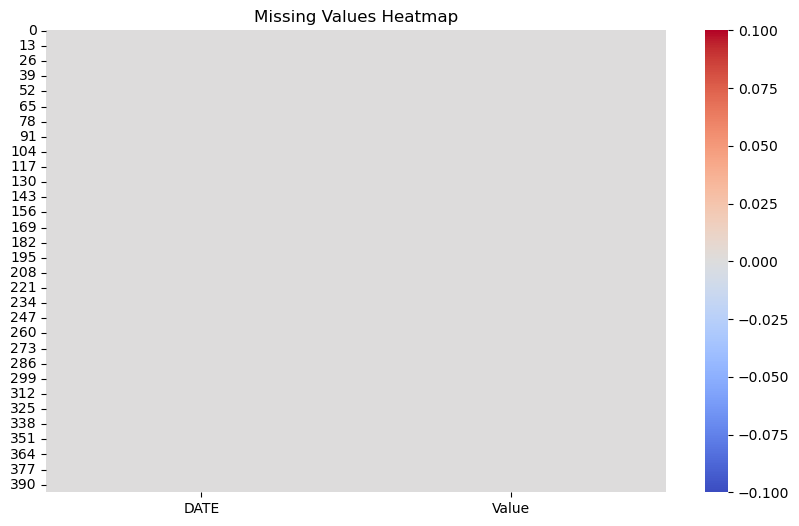

In [11]:
# plotting a heatmap of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cmap='coolwarm')
plt.title('Missing Values Heatmap')

plt.show()

#### There are no missing value


## DATA CLEANING

In [12]:
# Renaming 'Value' column
df.rename(columns = {'Value': 'E.Production_Value'}, inplace=True)

# DATA VISUALIZATION (EDA CONTINUES)

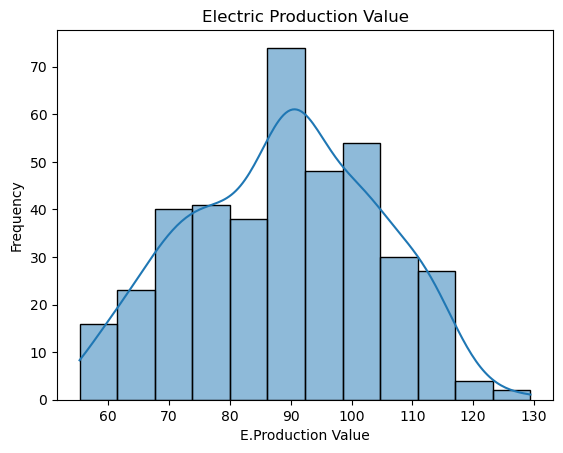

In [13]:
# histogram plot of our dataset
sns.histplot(df['E.Production_Value'], kde=True)
plt.xlabel('E.Production Value')
plt.ylabel('Frequency')
plt.title('Electric Production Value')
plt.show()

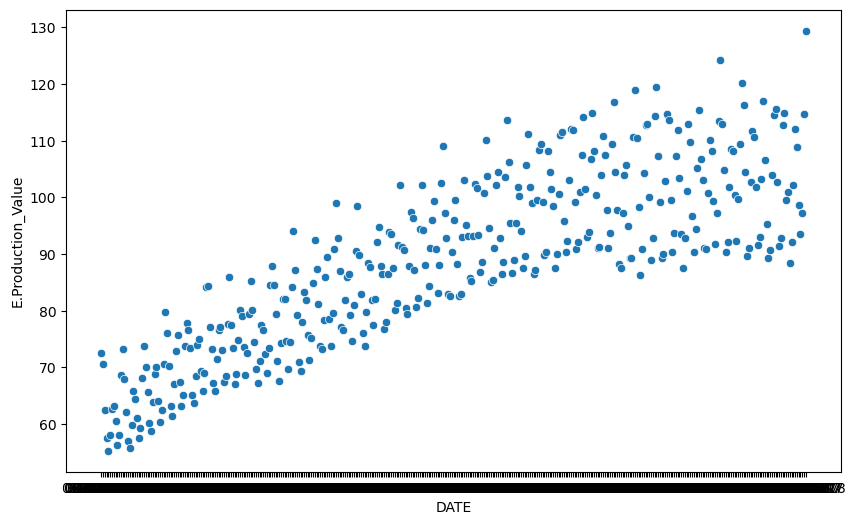

In [14]:
# scatterplot for electricity production values
plt.figure(figsize = (10,6))
sns.scatterplot(data=df, x='DATE', y='E.Production_Value')

plt.show()

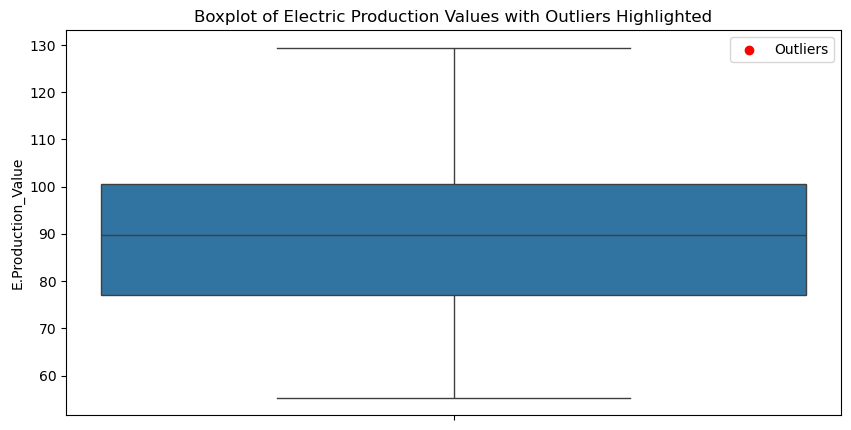

In [15]:
#checking for outliers with boxplot

plt.figure(figsize =(10,5))
sns.boxplot(y=df['E.Production_Value'])

# Identifing the points outside 1.5*IQR(inter-quatile range) as outliers
Q1 = df['E.Production_Value'].quantile(0.25)
Q3 = df['E.Production_Value'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['E.Production_Value'] < (Q1 - 1.5*IQR)) |
              (df['E.Production_Value'] > (Q3 + 1.5*IQR))]

# Plot the outliers on top
plt.scatter(outliers['E.Production_Value'], [1]*len(outliers), color='red', label='Outliers')

plt.title('Boxplot of Electric Production Values with Outliers Highlighted')
plt.legend()
plt.show()

### From the boxplot above, there are no outliers

<Axes: >

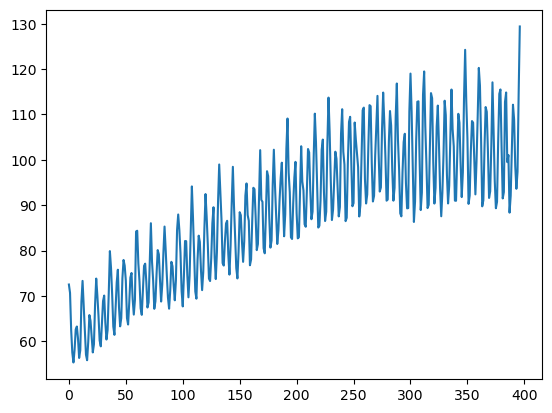

In [16]:
# distribution plot
df['E.Production_Value'].plot()

# TIME SERIES DECOMPOSITION

In [17]:
# transforming 'DATE' column to Datetime 
df['DATE'] = pd.to_datetime(df['DATE'])

df.set_index('DATE',inplace = True)

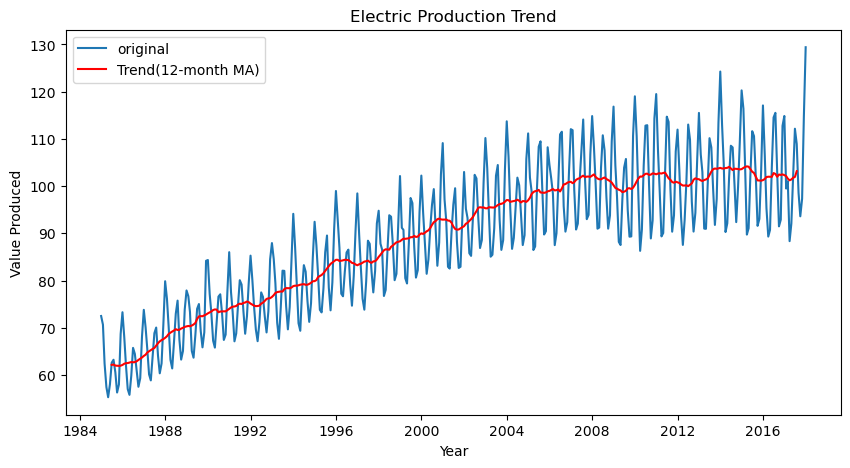

In [18]:
# plotting Trend for electric production
df['Trend'] = df['E.Production_Value'].rolling(window=12,center=True).mean()

plt.figure(figsize=(10,5))
plt.plot(df['E.Production_Value'], label = 'original')
plt.plot(df['Trend'], label='Trend(12-month MA)', color = 'red')
plt.title('Electric Production Trend')
plt.xlabel('Year')
plt.ylabel('Value Produced')
plt.legend()
plt.show()

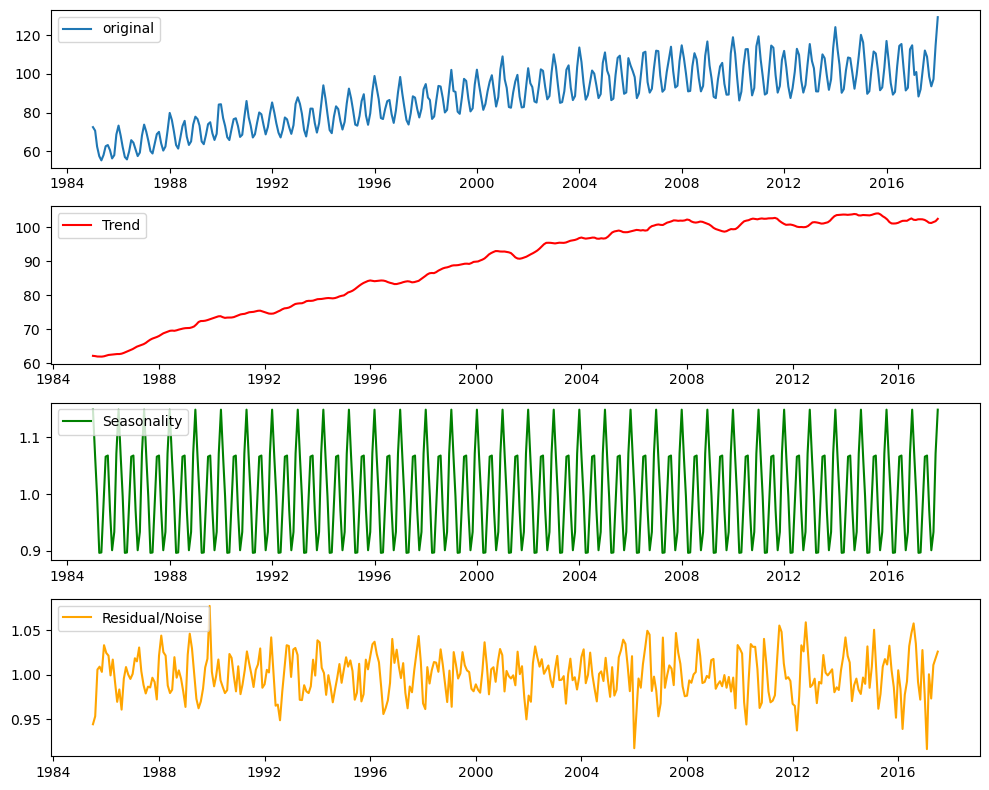

In [19]:
# decomposition plot for trend, residual and seasonality

decomposition = seasonal_decompose(df['E.Production_Value'], model = 'mutiplicative', period = 12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(10,8))

plt.subplot (4,1,1)
plt.plot(df['E.Production_Value'], label = 'original')
plt.legend(loc = 'upper left')

plt.subplot (4,1,2)
plt.plot(trend, label = 'Trend', color = 'red')
plt.legend(loc = 'upper left')

plt.subplot (4,1,3)
plt.plot(seasonal, label = 'Seasonality', color = 'green')
plt.legend(loc = 'upper left')

plt.subplot (4,1,4)
plt.plot(residual, label = 'Residual/Noise', color = 'orange')
plt.legend(loc = 'upper left')

plt.tight_layout()
plt.show()

### Our seasonal decomposition suggests
- There's a clear Trend, therefore data is unstable and therefore needs differencing or transformation
- There's a repeatative seasonal cycle, therefore dataset will be best captured by a SARIMA model with a low-order auto regressive and moving average, and 12 months seasonality
- There's white noise

## AUGUMENTED DICKER-FULLER TEST (STATIONARITY TEST)

In [20]:
# Dicker-Fuller, stationarity test
result = adfuller(df['E.Production_Value'])
print('ADf Statistic:', result[0])
print('p-vaue:', result[1])
if result[1] < 0.05:
    print('The series is likely stationary')
else:
    print('The series is likely non-stationary')

ADf Statistic: -2.25699035004724
p-vaue: 0.18621469116586942
The series is likely non-stationary


In [21]:
print(result)

(np.float64(-2.25699035004724), np.float64(0.18621469116586942), 15, 381, {'1%': np.float64(-3.4476305904172904), '5%': np.float64(-2.869155980820355), '10%': np.float64(-2.570827146203181)}, np.float64(1840.8474501627156))


# DIFFERENCING

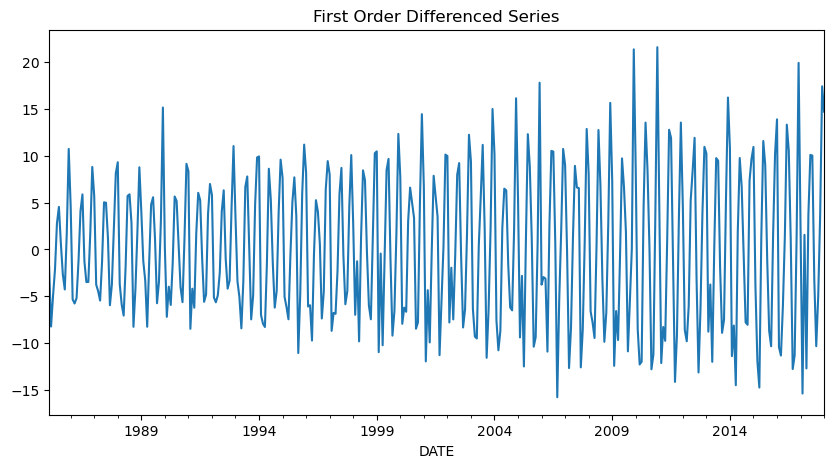

In [22]:
#Differencing our data
df['Diff_1'] = df['E.Production_Value']-df['E.Production_Value'].shift(1)

df_diff= df['Diff_1'].dropna()

#plotting our differenced data
df_diff.plot(title = 'First Order Differenced Series', figsize = (10,5))
plt.show()

In [23]:
# Dicker-fuller test after differencing
result = adfuller(df_diff)
print('ADf Statistic:', result[0])
print('p-vaue:', result[1])
if result[1] < 0.05:
    print('The series is likely stationary')
else:
    print('The series is likely non-stationary')

ADf Statistic: -7.104890882267346
p-vaue: 4.077786565538608e-10
The series is likely stationary


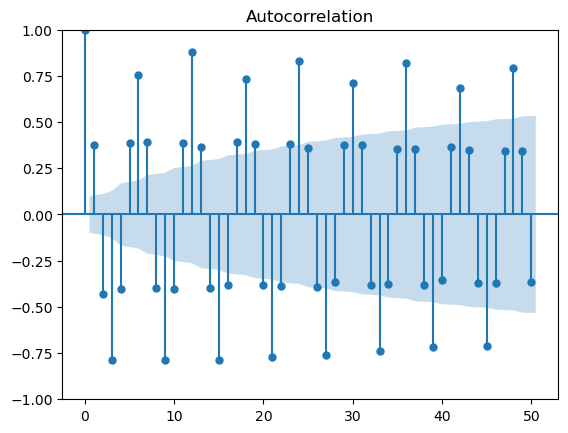

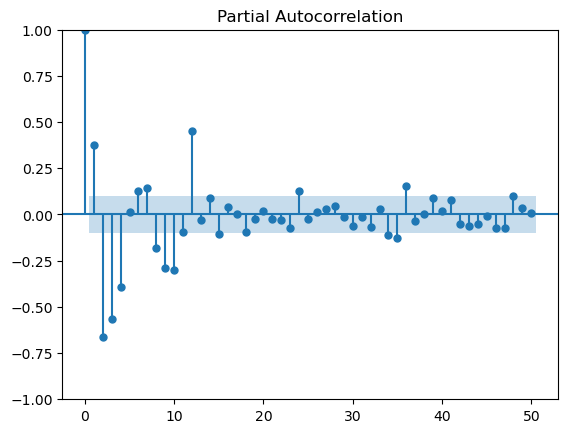

In [24]:
# Autocorrelation plot
plot_acf(df_diff, lags=50)
plt.show()

# Partial auto correlation Plot
plot_pacf(df_diff, lags=50)
plt.show()

#### The ACF and PACF chart suggest that there are no obvious seasonal pattern.
#### A non-seasonal Arima might be sufficient but already our decomposition also suggests SARIMA is the best model.

#### Due to sharp cutoff after lags 2, ACF suggests MA to be 2.
#### Also PACF suggests our AR to be 2 or 1.

#### We'll be trusting our ACF and PACF readings and apply the p and q values suggestted without checking for AIC and BIC readings (mostly because we dont yet completely understood how to interpret AIC and BIC as a Group).

# SPLITING OF TRAINING AND TESTING SETS 

In [25]:
# Train-Test splitting
train_size = int(len(df) * 0.8)

train = df['E.Production_Value'][:train_size]
test = df['E.Production_Value'][train_size:]

In [26]:
train.tail()

DATE
2011-01-01    119.4880
2011-02-01    107.3753
2011-03-01     99.1028
2011-04-01     89.3583
2011-05-01     90.0698
Name: E.Production_Value, dtype: float64

In [27]:
test.head()

DATE
2011-06-01    102.8204
2011-07-01    114.7068
2011-08-01    113.5958
2011-09-01     99.4712
2011-10-01     90.3566
Name: E.Production_Value, dtype: float64

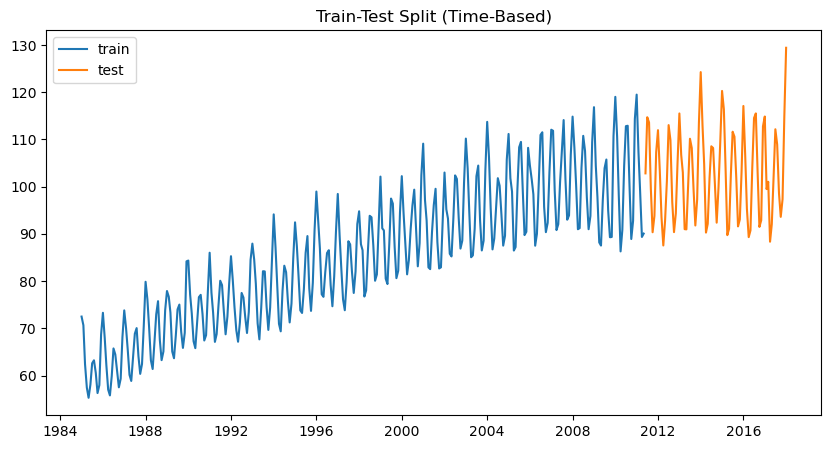

In [28]:
# Train-Test split Plotting
plt.figure(figsize=(10,5))
plt.plot(train, label = 'train')
plt.plot(test, label = 'test')
plt.legend()
plt.title('Train-Test Split (Time-Based)')
plt.show()

# BUILDING OUR MODEL WITH ARIMA

In [29]:
import warnings
warnings.filterwarnings('ignore')

In [30]:
# Building ARIMA Model

model = ARIMA(train, order=(1, 1, 2))
fitted_model = model.fit()

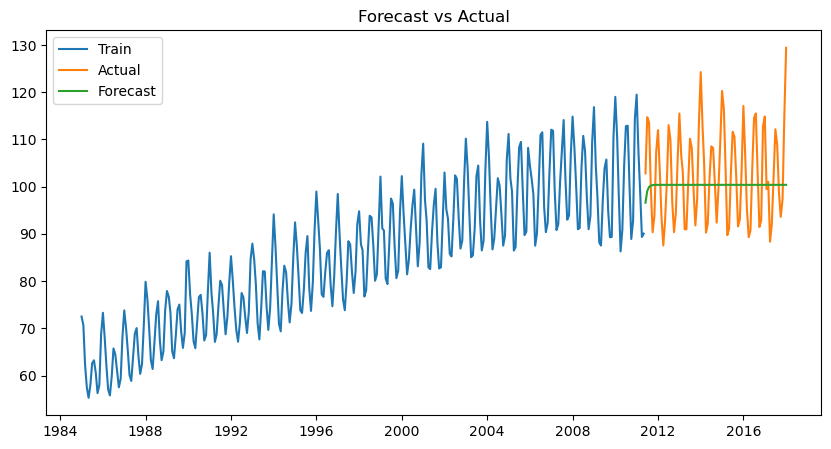

In [31]:
#plotting our trained data
forecast_1= fitted_model.forecast(steps=len(test))

plt.figure(figsize =(10, 5))
plt.plot(train, label = 'Train')
plt.plot(test, label = 'Actual')
plt.plot(forecast_1, label='Forecast')
plt.legend()
plt.title('Forecast vs Actual')

plt.show()

### Arima has short term memory and remembers only yesterday's value but not last years, therefore it failed. 

# BUILDING OUR MODEL WITH SARIMA

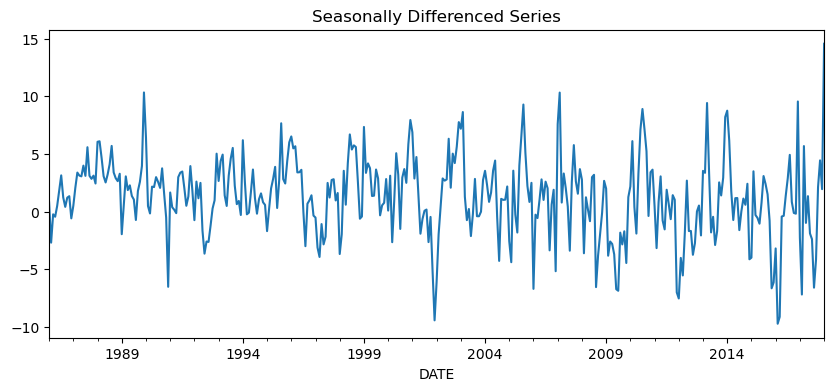

In [32]:
# seasonal Differencing of our data set
df['Seasonal_Diff'] = df['E.Production_Value'] - df['E.Production_Value'].shift(12)
df_seasonal = df['Seasonal_Diff'].dropna()

# plotting of our data set 
df_seasonal.plot(title="Seasonally Differenced Series", figsize=(10,4))
plt.show()


In [33]:
# Dicker-Fuller test for our differenced seasonal data
result = adfuller(df_seasonal)

print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary")

ADF Statistic: -5.673482023381765
p-value: 8.812644938088811e-07
The series is likely stationary


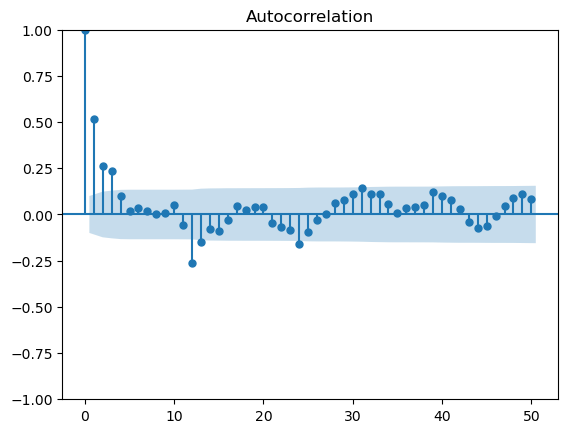

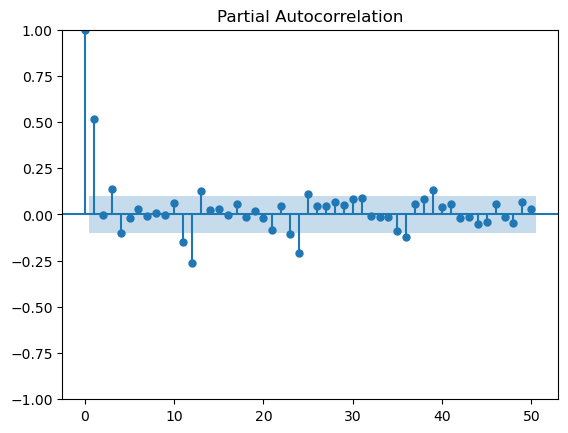

In [34]:

plot_acf(df_seasonal, lags=50)
plt.show()

# Partial auto correlation Plot
plot_pacf(df_seasonal, lags=50)
plt.show()

### Again, because we currently couldn't completely interprete AIC and BIC readings, we picked the sarima order intuitively

In [35]:
# model building
model = SARIMAX(
    train,
    order = (1, 1, 2),
    seasonal_order = (2, 1, 1, 12)
)
results = model.fit()

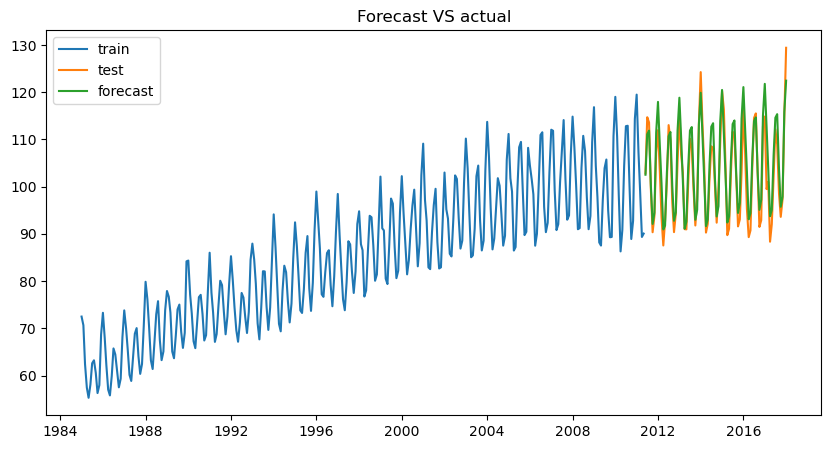

In [36]:
#forecast alignment on test sets
forecast_2 = results.get_forecast(steps=len(test)) 
forecast_aligned = pd.Series(forecast_2, index=test.index)
forecast_2 = forecast_2.predicted_mean 
forecast_2.index = test.index

#plotting of forecast on test sets
plt.figure(figsize=(10,5))
plt.plot(train, label = 'train')
plt.plot(test, label = 'test')
plt.plot(forecast_2, label = 'forecast')
plt.title('Forecast VS actual')
plt.legend()

plt.show()
                           

In [37]:
# testing errors with RMSE and MAE
rmse = mean_squared_error(test, forecast_2) 
mae = mean_absolute_error(test, forecast_2) 

print("RMSE:", rmse) 
print("MAE:", mae)

RMSE: 15.52259391114672
MAE: 3.1566523968278473


#### - The model produced a Mean Absolute Error (MAE) of 3.15, indicating that predictions deviate from the actual values by about 3 units on average.
#### - However, the Root Mean Squared Error (RMSE) of 15.52 is considerably higher, suggesting the presence of some large prediction errors, which increase the squared error metric.
#### - These large prediction errors is likely caused by volatility or sudden fluctuations in the time series data, where the model struggles to capture sudden change.

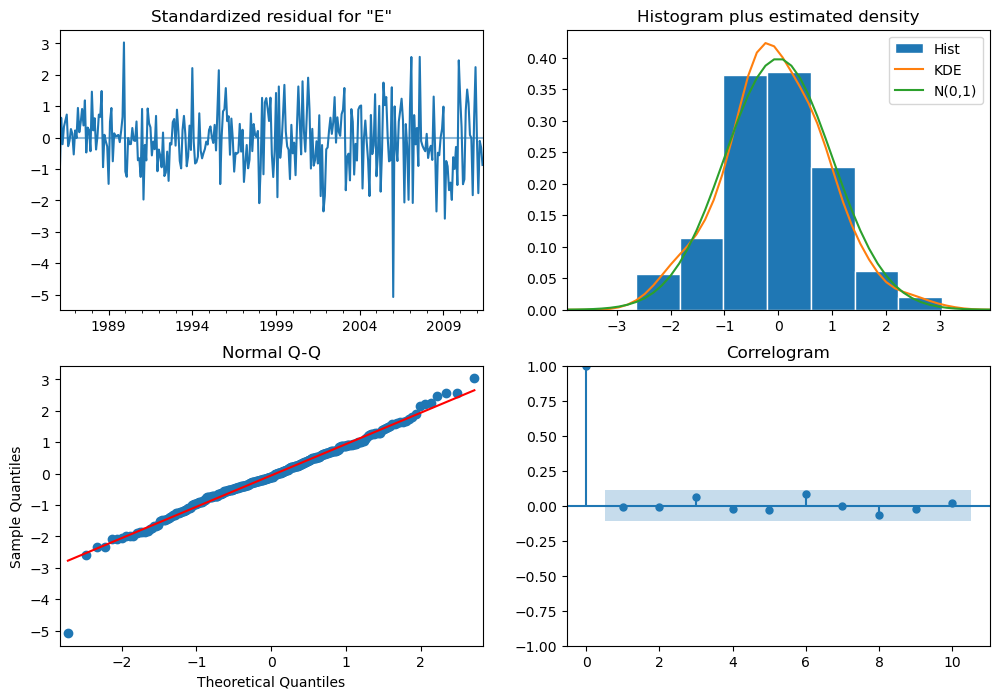

In [38]:
# plotting our model diagnosis

results.plot_diagnostics(figsize=(12,8))
plt.show()

#### diagnostics plot suggests;
- a normal residual distribution observed from the bell shaped kde
- A trendy plot suggests model might be missing something, possibly due its volatility
- QQ plot are close to the line suggesting normal distribution
- No significant spikes of lags outside the confidence zone of the ACF/PACF plot

In [39]:
# Residual Analysis
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                   E.Production_Value   No. Observations:                  317
Model:             SARIMAX(1, 1, 2)x(2, 1, [1], 12)   Log Likelihood                -670.504
Date:                              Sun, 15 Mar 2026   AIC                           1355.009
Time:                                      02:30:58   BIC                           1381.028
Sample:                                  01-01-1985   HQIC                          1365.417
                                       - 05-01-2011                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3248      0.126      2.582      0.010       0.078       0.571
ma.L1         -0.7102      0.123     -5.782      0.000      -0.951      -0.469
ma.L2         -0.2168      0.105     -2.070      0.038      -0.422      -0.012
ar.S.L12      -0.0809      0.103     -0.788      0.431      -0.282       0.120
ar.S.L24      -0.1808      0.083     -2.185      0.029      -0.343      -0.019
ma.S.L12      -0.6224      0.100     -6.215      0.000      -0.819      -0.426
sigma2         4.6409      0.317     14.620      0.000       4.019       5.263
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                46.05
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               2.61   Skew:                            -0.28
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Prob(Q) = 0.85 i.e P >0.05; thus we accept the Lunj Box null hypothesis. 
#### There's white noise (as previous confirmed in our decomposition plot), and has no auto correlation.
#### This simply means our model is Good and likely needs no futher improvement. 

### Prob(JB) = 0.00 i.e P < 0.05: thus we reject the Jacque Bera null hypothesis that the residual has a normal distribution. Residual is not normally distributed.

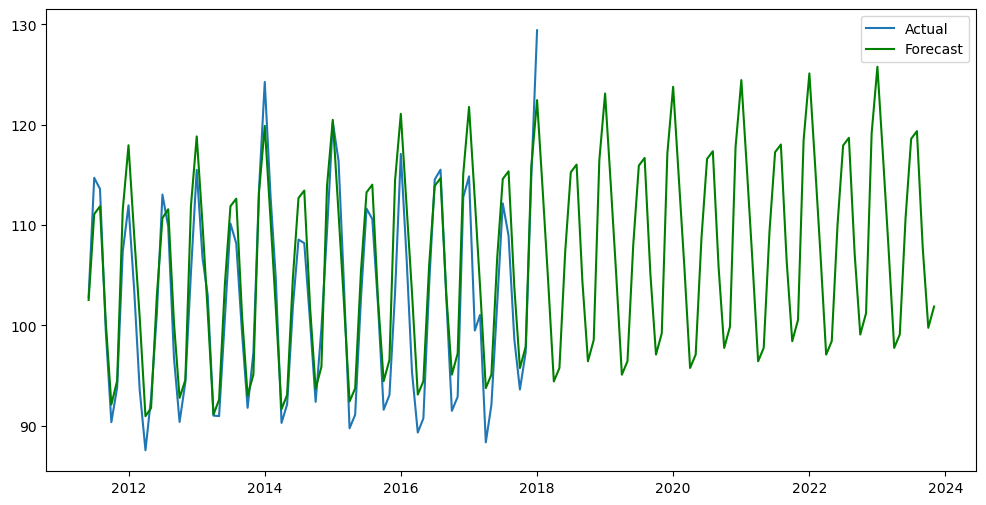

In [40]:
# forward prediction from trained model
forecast = results.get_forecast(steps=150)

#plotting predictions
plt.figure(figsize=(12, 6))
plt.plot(test, label='Actual')
plt.plot(forecast.predicted_mean, label='Forecast', color='green')
plt.legend()
plt.show()